<a href="https://colab.research.google.com/github/stenoe/FEDS/blob/main/notebooks/class_notebooks_2026/lecture4_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Create data, simple regresseion, first model

## What we gonna do

1. create some random data
2. using the random functions (numpy and statsmodels)
3. building a linear model
4. visualise the data
5. Perform linear regression
6. Use etimations for predictions

In [13]:
# load libraries

import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
import pandas as pd

In [14]:
# setting the scene

NDAT = 100

# seeding the random generators
rng = np.random.default_rng(seed=42)
rng2 = np.random.default_rng(seed=123)

In [15]:
# generate random numbers
x = rng.random(NDAT) * 50
x

array([38.69780243, 21.94392199, 42.929896  , 34.86840145,  4.70886739,
       48.78111758, 38.0569851 , 39.30321526,  6.40568163, 22.51929689,
       18.53990121, 46.33824944, 32.193256  , 41.13808066, 22.17070994,
       11.36193609, 27.72923935,  3.19086281, 41.3815586 , 31.58321996,
       37.904387  , 17.72629841, 48.53490122, 44.65605607, 38.91917485,
        9.73193539, 23.33605019,  2.19018829,  7.7144746 , 34.15244766,
       37.2381078 , 48.37548662, 16.29126791, 18.5229853 , 23.47779056,
        9.47356795,  6.49607527, 23.78524631, 11.34546745, 33.49069973,
       21.85759594, 41.6339098 , 35.0132551 , 15.61833207, 41.61299007,
       40.23821787, 19.37391895, 14.4164052 , 34.1247752 ,  6.98762418,
        9.99541012,  0.36811349, 39.34621888, 33.24254283, 35.25826893,
       39.03645155, 22.94578878, 28.4370598 ,  6.98984991,  5.72650368,
       33.42014809, 23.55481031, 28.26180532, 38.24994287, 31.735916  ,
       27.67897003, 27.96035804, 15.1975049 ,  1.54089173, 21.83

In [16]:
# Create a normal distributed set of random numbers

e = rng2.normal(loc=0.0, scale=10.0, size=NDAT)
e

array([ -9.8912135 ,  -3.67786651,  12.87925261,   1.93974419,
         9.202309  ,   5.77103791,  -6.36463646,   5.4195222 ,
        -3.16595451,  -3.22389116,   0.97167319, -15.25930407,
        11.92166104,  -6.71089675,  10.0026942 ,   1.36321124,
        15.3203308 ,  -6.59969414,  -3.11794856,   3.37769127,
       -22.07471098,   8.27921442,  15.41630395,  11.26806793,
         7.54769644,  -1.45977893,  12.81902227,  10.74030622,
         3.92620845,   0.05114313,  -3.61766872, -12.30232195,
        12.26229293, -21.72043887,  -3.70147346,   1.6438007 ,
         8.59881185,  17.61661237,   9.93323776,  -2.91521426,
         7.28127558, -12.61600317,  14.29938527,  -1.56475325,
        -6.7375915 ,  -6.390601  ,  -0.61361328,  -3.92784923,
        22.89909947,  -7.18181148,   0.32607743,   0.28049896,
         0.28272123,   0.55345862,  -4.81562858,  -5.834075  ,
        -8.62160502, -14.88174613,   2.16306833,   9.84376351,
        -5.43084141,  -5.58615039,  -3.16482829,  -4.60

(array([ 2.,  3.,  7., 17., 24., 16., 10., 13.,  7.,  1.]),
 array([-22.07471098, -17.57732994, -13.07994889,  -8.58256785,
         -4.0851868 ,   0.41219425,   4.90957529,   9.40695634,
         13.90433738,  18.40171843,  22.89909947]),
 <BarContainer object of 10 artists>)

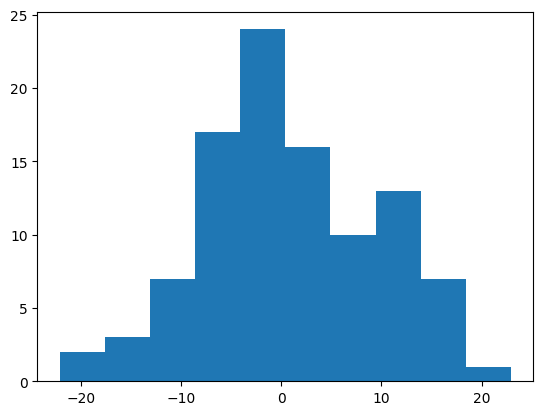

In [17]:
plt.hist(e)

In [18]:
# let's create a function

def greet(name):
  return f"Hello {name}, how are you today?"

greet("Steffen")

'Hello Steffen, how are you today?'

In [19]:
# Create a function to define linear model y = m*x + b + err

def my_linear_model(x, m=4, b=20, error=0):
  return m * x + b + error


In [20]:
y = my_linear_model(x, error=e)
y

array([164.89999621, 104.09782144, 204.5988366 , 161.41335   ,
        48.03777857, 220.89550824, 165.86330393, 182.63238326,
        42.45677202, 106.85329642,  95.13127803, 190.0936937 ,
       160.69468506, 177.8414259 , 118.68553396,  66.8109556 ,
       146.2372882 ,  26.16375708, 182.40828583, 149.71057109,
       149.54283704,  99.18440804, 229.55590883, 209.8922922 ,
       183.22439586,  57.46796264, 126.16322302,  39.50105938,
        54.78410686, 156.66093378, 165.33476246, 201.19962453,
        97.42736456,  72.37150234, 110.2096888 ,  59.53807251,
        54.58311291, 132.75759761,  75.31510757, 151.04758468,
       114.71165935, 173.91963604, 174.35240567,  80.90857503,
       179.71436878, 174.5622705 ,  96.88206253,  73.73777156,
       179.39820027,  40.76868524,  60.30771793,  21.75295291,
       177.66759673, 153.52362994, 156.21744714, 170.3117312 ,
       103.16155009, 118.86649306,  50.12246796,  52.74977821,
       148.24975095, 108.63309084, 129.882393  , 168.39

In [21]:
df = pd.DataFrame({
    "x": x,
    "y": y,
    "e": e
    })
df.head()

,x,y,e
0,38.697802,164.899996,-9.891214
1,21.943922,104.097821,-3.677867
2,42.929896,204.598837,12.879253
3,34.868401,161.413350,1.939744
4,4.708867,48.037779,9.202309


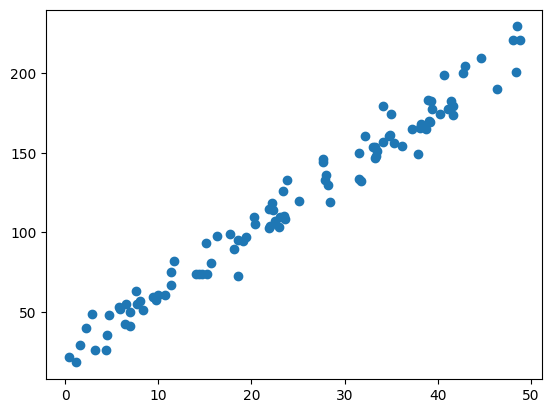

In [22]:
plt.scatter(df.x,df.y)

## Run some statistics on the generated data

In [23]:
# run a linear regression

lm = sps.linregress(df.x, df.y)
lm

# make informtion readable
print(f"Regression result: y = {lm.slope:.2f} * x + {lm.intercept:.2f}")
print(f"True values      : y =  {4} * x + {20}\n")
print(f"r-squared        : {lm.rvalue:.6f}")
print(f"p-value          : {lm.pvalue:.6f} => {lm.pvalue:.6g}")

# run a student t-test on the data
from scipy.stats import t
tinv = lambda p, dfr: abs(t.ppf(p, dfr)) # create a t-test table with probability p and degree of freedom dfr
ts = tinv(0.05, len(df.x)-2) # calculate the t-value from the table dfr -2 is two sided test

print(f"t-value          : {ts:.6f}")
print(f"slope 95%        : {lm.slope:.6f} +/- {ts*lm.stderr:.6f}")
print(f"intercept 95%    : {lm.intercept:.6f} +/- {ts*lm.intercept_stderr:.6f}")

Regression result: y = 3.92 * x + 22.66
True values      : y =  4 * x + 20

r-squared        : 0.986432
p-value          : 0.000000 => 1.02175e-78
t-value          : 1.660551
slope 95%        : 3.924518 +/- 0.109559
intercept 95%    : 22.656070 +/- 3.054971


## The Percentage Point Function (PPF)

The Percentage Point Function (PPF), also known as the inverse cumulative distribution function (CDF), is the mathematical function that provides the value for which a given percentage of observations fall below. In simpler terms, it gives the cutoff value for a specified percentile or probability.

For example, if you have a normal distribution and you want to find the value below which 95% of the data falls, you would use the PPF to obtain this value.

The PPF is the inverse of the CDF. While the CDF gives the probability that a random variable is less than or equal to a specified point, the PPF gives the point for which a certain probability is less than or equal to.

We used this in the Student's t-test when we created the table and set the `t.ppf` parameter to 0.05 which is the 95% cut-off criteria.

## Try to make predictions

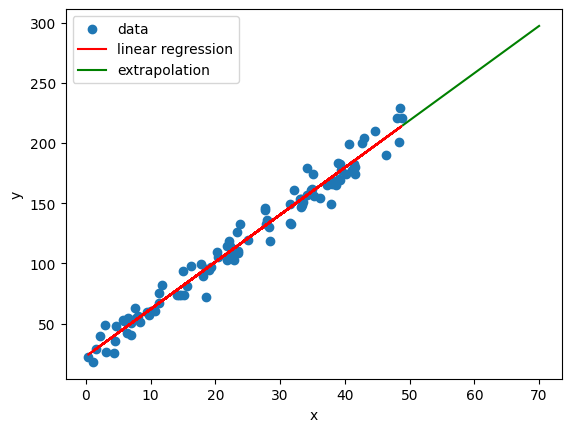

In [24]:
# Create new x values for extrapolation
EXTRAPOL = 70

ext_points = [round(max(x)), EXTRAPOL]
line_points = [0, max(x)]

# plot data
plt.scatter(df.x, df.y,label="data")

# plot regression
plt.plot(df.x, lm.intercept + lm.slope * df.x, color="red", label="linear regression")


# plot the extrapolation
plt.plot(ext_points, lm.slope*np.array(ext_points) + lm.intercept, color="green", label="extrapolation")

plt.legend()
plt.xlabel("x")
plt.ylabel("y");

## Regression using the statsmodel library

In [25]:
# import the library
import statsmodels.formula.api as sm
import seaborn as sns

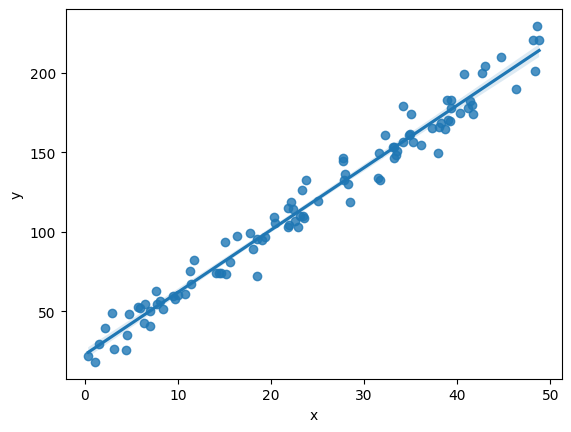

In [26]:
sns.regplot(data=df, x="x", y="y");

In [27]:
# regression
lm_sm = sm.ols(formula="y ~ x", data=df).fit()

print(lm_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     3538.
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           1.02e-78
Time:                        14:03:06   Log-Likelihood:                -360.40
No. Observations:                 100   AIC:                             724.8
Df Residuals:                      98   BIC:                             730.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     22.6561      1.840     12.315      0.0

In [28]:
# make that super compact
print(
    sm.ols(formula="y ~ x", data=df).fit().summary()
)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     3538.
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           1.02e-78
Time:                        14:03:06   Log-Likelihood:                -360.40
No. Observations:                 100   AIC:                             724.8
Df Residuals:                      98   BIC:                             730.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     22.6561      1.840     12.315      0.0

## how the sample size impacts on the normal distribution

In [29]:
rng = np.random.default_rng(seed=42)
mu, sigma = 0, 10
SAMPLE_SIZE = 1000 # cahnge it to larger numbers

aa = rng.normal(mu, sigma, SAMPLE_SIZE)
print(f"deviation mu : {abs(mu - np.mean(aa))}, deviation sigma : {abs(sigma - np.std(aa, ddof=1))} ")


deviation mu : 0.28891550995946846, deviation sigma : 0.10782912345664108 


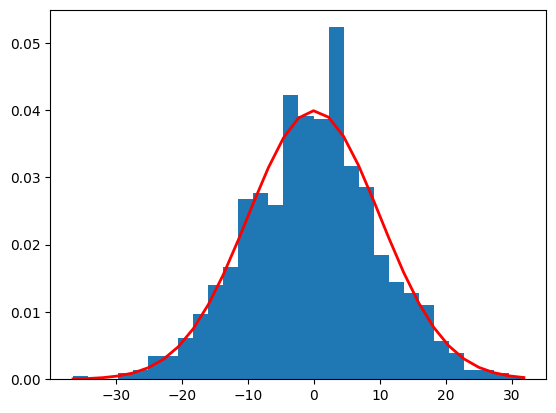

In [30]:
# visualise the sample size for the normal distribution

counts, bins, ignored = plt.hist(aa, 30, density=True)

plt.plot(bins,
         1/(sigma * np.sqrt(2 * np.pi)) *
         np.exp( - (bins - mu)**2 / (2 * sigma**2)) ,
                linewidth=2, color='r')
plt.show()

## Lambda functions vs normal functions

The use of Lambda functions has some benefits if the task can be solved with one expression (literally one line of code) like defining the simple linear relation $y = mx + b + \textrm{err}$ that is just one line of code. They live in the main programs context space.

Normal functions are often used for more complex tasks where more lines of code are used within the function. They can change the context space (use e.g., same variable names that are valid only inside the function block as the main program is using), they only return values when used the `return` keyword is used.

In [31]:
# Create a function to define linear model y = m*x + b + err

def my_linear_model(x, m=4, b=20, error=0):
  return m * x + b + error


In [32]:
my_linear_model_lambda = lambda x, m=4, b=20, error=0: m * x + b + error

| Feature	| def Function	| lambda Function |
|---------|---------------|-----------------|
| Definition	| Defined using the def keyword	| Defined using the lambda keyword |
| Function Name	| Requires a name (unless inside another function)	| Anonymous (no name unless assigned to a variable) |
| Number of Expressions	| Can have multiple expressions and statements	| Can have only a single expression |
| Readability	| More readable, especially for complex logic	| Less readable for complex operations |
| Return Statement	| Uses return explicitly to return a value	| Implicitly returns the result of the expression |
| Use Case	| Used for defining reusable functions with multiple operations	| Used for short, throwaway functions |
| Supports Loops and Conditions	| Can include loops, multiple conditions, and multi-line statements	| Can only contain a single expression, no loops |
| Code Complexity	| Suitable for complex functions	| Best for simple, one-liner functions |
| Assignment to Variable	| Defined independently with a function name	| Can be assigned to a variable for reuse |

